# AI Judge Assistant — OCR Pipeline (Testing)

Simplified OCR pipeline for camera-captured Arabic legal documents.

**Pipeline layers:**
1. Document Ingestion — load PDF/image, convert to PIL Images
2. Image Restoration — RGB conversion, resize, CLAHE contrast normalization
3. Perspective Correction — DocTR-based document dewarping
4. OCR Engine — QARI (full-page, one call per page)
5. Text Reconstruction — numeral normalization, raw + normalized text
6. Output — structured JSON

## 0. Setup & Imports

Install all required packages and import everything the pipeline needs.
Run this cell once at the start of each session.

In [1]:
# ── Installs ──────────────────────────────────────────────────────────
%pip install -q transformers accelerate bitsandbytes huggingface-hub
%pip install -q qwen-vl-utils
%pip install -q "python-doctr[torch]"
%pip install -q pdf2image Pillow
%pip install -q opencv-python-headless

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ── Standard library ─────────────────────────────────────────────────
import json
import logging
import os
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# ── Third-party ───────────────────────────────────────────────────────
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

# ── Logging ────────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

print("All imports successful.")

All imports successful.


## 1. Configuration

All hardcoded pipeline variables live here: model name, file path, token,
max tokens. Edit this cell to point at your test document.

In [2]:
# ── Model ─────────────────────────────────────────────────────────────
MODEL_NAME = "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct"
MAX_NEW_TOKENS = 4000

# ── Input file ────────────────────────────────────────────────────────
# Change this to the path of your test document (image or PDF)
FILE_PATH = "E:\\Anaconda3\\envs\\Judge-Assistant\\Case Sample\\Case_Sample(11).jpeg"


# ── PDF conversion DPI (only used for PDF files) ─────────────────────
PDF_DPI = 400


# ── Image restoration ─────────────────────────────────────────────────
MAX_IMAGE_DIMENSION = 4000
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)


# ── Perspective Correction ─────────────────────────────────────────────────────
# Approach 1 (Contour Detection)
MIN_AREA_RATIO    = 0.35    # minimum contour area as fraction of image
CANNY_LOW         = 50     # Canny low threshold
CANNY_HIGH        = 150    # Canny high threshold
BLUR_KERNEL       = (5, 5) # Gaussian blur kernel size
DILATE_KERNEL     = (3, 3) # Dilation kernel size
DILATE_ITERATIONS = 1      # Dilation iterations
TOP_N_CONTOURS    = 5      # How many largest contours to check
APPROX_EPSILON_CD = 0.02   # Contour simplification tolerance
EXPAND_MARGIN_CD  = 0.02   # Quad expansion margin

# Approach 2 (Adaptive Threshold)
BLOCK_SIZE         = 35     # adaptive threshold block size (must be odd)
C_CONSTANT         = -10    # threshold constant (more negative = stricter)
CLOSE_KERNEL       = (30, 30)  # morphological close kernel
CLOSE_ITERATIONS   = 2        # close iterations
OPEN_KERNEL        = (15, 15)   # morphological open kernel
OPEN_ITERATIONS    = 1        # open iterations
APPROX_EPSILON_AT  = 0.02     # contour simplification tolerance
EXPAND_MARGIN_AT   = 0.02     # quad expansion margin


# ── OCR prompt ────────────────────────────────────────────────────────
OCR_PROMPT = (
    "You are a strict OCR engine transcribing Arabic legal documents. "
    "Transcribe exactly what is written in this image. "
    "Do NOT correct spelling, grammar, punctuation, or any perceived mistakes. "
    "Do NOT add or remove any words. "
    "If something looks like a typo or error, transcribe it exactly as-is. "
    "Preserve all text exactly character by character."
)


# ── HuggingFace login ─────────────────────────────────────────────────
from huggingface_hub import login

if token := os.environ.get("HF_TOKEN"):
    login(token)
    print("HuggingFace login successful.")
else:
    print("HF_TOKEN not set — skipping login. Private models will not be accessible.")

print(f"Model: {MODEL_NAME}")
print(f"File:  {FILE_PATH}")

HF_TOKEN not set — skipping login. Private models will not be accessible.
Model: NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct
File:  E:\Anaconda3\envs\Judge-Assistant\Case Sample\Case_Sample(11).jpeg


## 2. Model Loading

Load the QARI OCR model with 8-bit quantization for memory efficiency.
This cell only needs to run once per session — all other cells reuse
the `model` and `processor` objects created here.

In [3]:
print(f"Loading QARI model: {MODEL_NAME}")

bnb_config = BitsAndBytesConfig(load_in_8bit=True)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(MODEL_NAME, use_fast=False)

print("QARI model loaded successfully.")

Loading QARI model: NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct


INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/dabe11e3990176858b26eacfef3ee16fff1d5970/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/dabe11e3990176858b26eacfef3ee16fff1d5970/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/dabe11e3990176858b26eacfef3ee16fff1d5970/generation_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/dabe11e3990176858b26eacfef3ee16fff1d5970/preprocessor_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404

QARI model loaded successfully.


## 3. Document Ingestion

Load the input file (PDF or image) and convert it to a list of PIL Images,
one per page. Single images become a one-element list.

In [4]:
SUPPORTED_IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".webp"}
SUPPORTED_PDF_EXTENSIONS = {".pdf"}


def ingest_document(file_path: str, pdf_dpi: int = 400) -> List[Image.Image]:
    """
    Load a PDF or image file and return a list of PIL Images (one per page).
    """
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"File does not exist: {path}")
    if not path.is_file():
        raise ValueError(f"Path is not a file: {path}")

    suffix = path.suffix.lower()

    if suffix in SUPPORTED_PDF_EXTENSIONS:
        from pdf2image import convert_from_path
        print(f"Converting PDF to images at {pdf_dpi} DPI: {path.name}")
        pil_pages = convert_from_path(str(path), dpi=pdf_dpi)
        # Ensure RGB
        pages = [p.convert("RGB") if p.mode != "RGB" else p for p in pil_pages]
        print(f"PDF converted: {len(pages)} page(s)")
        return pages

    elif suffix in SUPPORTED_IMAGE_EXTENSIONS:
        print(f"Loading image: {path.name}")
        img = Image.open(path)
        img.verify()
        img = Image.open(path)  # re-open after verify
        if img.mode != "RGB":
            img = img.convert("RGB")
        print(f"Image loaded: {img.size[0]}x{img.size[1]}")
        return [img]

    else:
        raise ValueError(f"Unsupported file type: {suffix}")


# ── Run ingestion ─────────────────────────────────────────────────────
pages = ingest_document(FILE_PATH, pdf_dpi=PDF_DPI)
print(f"\nTotal pages: {len(pages)}")
for i, p in enumerate(pages):
    print(f"  Page {i + 1}: {p.size[0]}x{p.size[1]}")

Loading image: Case_Sample(11).jpeg
Image loaded: 899x1599

Total pages: 1
  Page 1: 899x1599


## 4. Image Restoration

Lightweight preprocessing — no heavy denoising or learned models:
1. Ensure RGB mode
2. Resize if the largest dimension exceeds 4000 px (preserve aspect ratio)
3. Apply CLAHE contrast normalization

In [5]:
def restore_image(pil_image: Image.Image) -> Image.Image:
    """
    Lightweight image restoration:
    1. Convert to RGB if needed
    2. Resize if largest dimension > MAX_IMAGE_DIMENSION
    3. CLAHE contrast normalization
    """
    # 1. RGB conversion
    if pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")

    # 2. Resize if too large
    w, h = pil_image.size
    max_dim = max(w, h)
    if max_dim > MAX_IMAGE_DIMENSION:
        scale = MAX_IMAGE_DIMENSION / max_dim
        new_w = int(w * scale)
        new_h = int(h * scale)
        pil_image = pil_image.resize((new_w, new_h), Image.LANCZOS)
        print(f"   Resized: {w}x{h} -> {new_w}x{new_h}")

    # 3. CLAHE contrast normalization
    img_array = np.array(pil_image)
    lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_TILE_GRID_SIZE,
    )
    l_enhanced = clahe.apply(l_ch)
    merged = cv2.merge((l_enhanced, a_ch, b_ch))
    enhanced_rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return Image.fromarray(enhanced_rgb)


# ── Run restoration ───────────────────────────────────────────────────
restored_pages: List[Image.Image] = []
for i, page in enumerate(pages):
    print(f"Restoring page {i + 1}...")
    restored_pages.append(restore_image(page))

print(f"\nRestoration complete: {len(restored_pages)} page(s)")

Restoring page 1...

Restoration complete: 1 page(s)


## 5. Perspective Correction

These documents are camera-captured photos with tilt, perspective distortion,
and background noise. This layer uses edge-based computer vision to detect the
physical page boundary and dewarp the image.

A tiered fallback strategy is used:
1. **Edge-based contour detection** -- Canny edges + largest quadrilateral contour
2. **Adaptive threshold page mask** -- segment light page from dark background
3. **Passthrough** -- if neither approach is confident, pass the original image through

Safety guards prevent aggressive cropping (minimum area ratio, maximum crop ratio,
aspect ratio sanity, and a padding buffer).


In [6]:
# ── Perspective Correction (Edge-based) ─────────────────────────────────
# ── Helpers ─────────────────────────────────────────────────────────────
def order_points(pts: np.ndarray) -> np.ndarray:
    """
    Order four corner points as: top-left, top-right, bottom-right, bottom-left.
    """
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left: smallest sum
    rect[2] = pts[np.argmax(s)]   # bottom-right: largest sum
    d = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(d)]   # top-right: smallest diff
    rect[3] = pts[np.argmax(d)]   # bottom-left: largest diff
    return rect


def expand_quad(pts: np.ndarray, img_shape: Tuple[int, ...], margin_pct: float = 0.02) -> np.ndarray:
    """
    Expand a quadrilateral outward from its center by margin_pct to avoid
    clipping text at the very edge of the page.
    """
    h, w = img_shape[:2]
    center = pts.mean(axis=0)
    expanded = center + (pts - center) * (1 + margin_pct)
    expanded[:, 0] = np.clip(expanded[:, 0], 0, w - 1)
    expanded[:, 1] = np.clip(expanded[:, 1], 0, h - 1)
    return expanded.astype(np.float32)


# ── Contour Detection (Approach 1) ─────────────────────────────────
def detect_page_contour(img_array: np.ndarray) -> Optional[np.ndarray]:
    """
    Approach 1: Edge-based contour detection.
    Finds the largest quadrilateral contour that covers at least min_area_ratio
    of the image area. Returns 4 corner points or None.
    """
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
    edges = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)

    # Dilate edges to close gaps caused by shadows or low contrast
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, DILATE_KERNEL)
    edges = cv2.dilate(edges, kernel, iterations=DILATE_ITERATIONS)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    h, w = img_array.shape[:2]
    img_area = w * h

    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for contour in contours[:TOP_N_CONTOURS]:       
        area = cv2.contourArea(contour)
        if area < img_area * MIN_AREA_RATIO:
            continue

        peri = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, APPROX_EPSILON_CD * peri, True)

        if len(approx) == 4:
            return approx.reshape(4, 2)

    return None

# ── Adaptive Threshold (Approach 2) ─────────────────────────────────
def detect_page_threshold(img_array: np.ndarray) -> Optional[np.ndarray]:
    """
    Approach 2: Adaptive threshold fallback.
    Segments the light page from the darker background using adaptive thresholding,
    then finds the largest connected component and returns its bounding quad.
    """
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape[:2]
    img_area = w * h

    # Adaptive threshold: light page becomes white, dark background becomes black
    binary = cv2.adaptiveThreshold(
        gray, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 
        BLOCK_SIZE, 
        C_CONSTANT
    )

    # Morphological close to fill small gaps within the page
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, CLOSE_KERNEL)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=CLOSE_ITERATIONS)

    # Remove small noise blobs
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, OPEN_KERNEL)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_open, iterations=OPEN_ITERATIONS)

    # Find contours on the binary mask
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    # Pick the largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    if area < img_area * MIN_AREA_RATIO:
        return None

    # Try to approximate to 4 corners first
    peri = cv2.arcLength(largest, True)
    approx = cv2.approxPolyDP(largest, APPROX_EPSILON_AT * peri, True)

    if len(approx) == 4:
        return approx.reshape(4, 2)

    # Fall back to minAreaRect
    rect = cv2.minAreaRect(largest)
    box = cv2.boxPoints(rect)
    return box.astype(np.float32)

# ── Safety Guards ─────────────────────────────────────────────────
def _check_safety_guards(
    src_pts: np.ndarray,
    dst_w: int,
    dst_h: int,
    orig_w: int,
    orig_h: int,
    min_dim_ratio: float = 0.65,
    min_area_ratio: float = MIN_AREA_RATIO,
) -> Tuple[bool, str]:
    """
    Validate that the perspective correction result is not too aggressive.
    Returns (is_safe, reason).
    """
    # Check minimum dimensions
    if dst_w < 100 or dst_h < 100:
        return False, f'output too small ({dst_w}x{dst_h})'

    # Maximum crop ratio: output must be >= 70% of original in each axis
    w_ratio = dst_w / orig_w
    h_ratio = dst_h / orig_h
    if w_ratio < min_dim_ratio or h_ratio < min_dim_ratio:
        return False, f'crops too aggressively (w_ratio={w_ratio:.2f}, h_ratio={h_ratio:.2f})'

    # Minimum area ratio
    area_ratio = (dst_w * dst_h) / (orig_w * orig_h)
    if area_ratio < min_area_ratio:
        return False, f'output area too small ({area_ratio:.2f} of original)'

    # Aspect ratio sanity: if original is portrait, output should not be landscape
    orig_portrait = orig_h > orig_w
    out_portrait = dst_h > dst_w
    if orig_portrait and not out_portrait:
        # Allow a small tolerance for nearly-square results
        if dst_w / dst_h > 1.15:
            return False, 'portrait original became landscape output'

    return True, 'ok'


# ── Main perspective correction function ─────────────────────────────────
def perspective_correct(pil_image: Image.Image) -> Tuple[Image.Image, bool]:
    """
    Detect the physical page boundary using edge-based computer vision and
    dewarp the image. Uses a tiered fallback:
      1. Edge-based contour detection
      2. Adaptive threshold page mask
      3. Passthrough (return original unchanged)

    Returns the corrected PIL Image and a boolean indicating whether
    correction was applied.
    """
    img_array = np.array(pil_image)
    h, w = img_array.shape[:2]

    try:
        # Try approach 1: edge-based
        page_quad = detect_page_contour(img_array)
        method = 'edge-contour'

        # Try approach 2: adaptive threshold
        if page_quad is None:
            page_quad = detect_page_threshold(img_array)
            method = 'adaptive-threshold'

        # Approach 3: Passthrough
        if page_quad is None:
            print('   No page boundary detected by any method -- passing through.')
            return pil_image, False

        print(f'   Page boundary detected via {method}')

        # Expand the quad slightly to avoid clipping edge text
        page_quad = expand_quad(page_quad.astype(np.float32), img_array.shape, margin_pct=EXPAND_MARGIN_CD if method == 'edge-contour' else EXPAND_MARGIN_AT)

        # Order points and compute destination dimensions
        src_pts = order_points(page_quad)

        dst_w = int(max(
            np.linalg.norm(src_pts[1] - src_pts[0]),
            np.linalg.norm(src_pts[2] - src_pts[3]),
        ))
        dst_h = int(max(
            np.linalg.norm(src_pts[3] - src_pts[0]),
            np.linalg.norm(src_pts[2] - src_pts[1]),
        ))

        # Safety guards
        is_safe, reason = _check_safety_guards(src_pts, dst_w, dst_h, w, h)
        if not is_safe:
            print(f'   Safety guard triggered: {reason} -- passing through.')
            return pil_image, False

        dst_pts = np.array([
            [0,         0        ],
            [dst_w - 1, 0        ],
            [dst_w - 1, dst_h - 1],
            [0,         dst_h - 1],
        ], dtype=np.float32)

        M = cv2.getPerspectiveTransform(src_pts, dst_pts)
        warped = cv2.warpPerspective(
            img_array, M, (dst_w, dst_h),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(255, 255, 255),
        )

        print(f'   Perspective corrected ({method}): {w}x{h} -> {dst_w}x{dst_h}')
        return Image.fromarray(warped), True

    except Exception as exc:
        print(f'   Perspective correction failed: {exc} -- passing through original.')
        return pil_image, False


# ── Run perspective correction on all pages ────────────────────────────
corrected_pages: List[Image.Image] = []
page_corrections: List[bool] = []

for i, page in enumerate(restored_pages):
    print(f'Perspective correction -- page {i + 1}...')
    corrected, was_corrected = perspective_correct(page)
    corrected_pages.append(corrected)
    page_corrections.append(was_corrected)
    if not was_corrected:
        print(f'   Page {i + 1}: passed through unchanged.')

print(f'\nPerspective correction complete: {len(corrected_pages)} page(s)')
print(f'Corrected: {sum(page_corrections)} / {len(page_corrections)}')

Perspective correction -- page 1...
   Page boundary detected via adaptive-threshold
   Perspective corrected (adaptive-threshold): 899x1599 -> 898x1598

Perspective correction complete: 1 page(s)
Corrected: 1 / 1


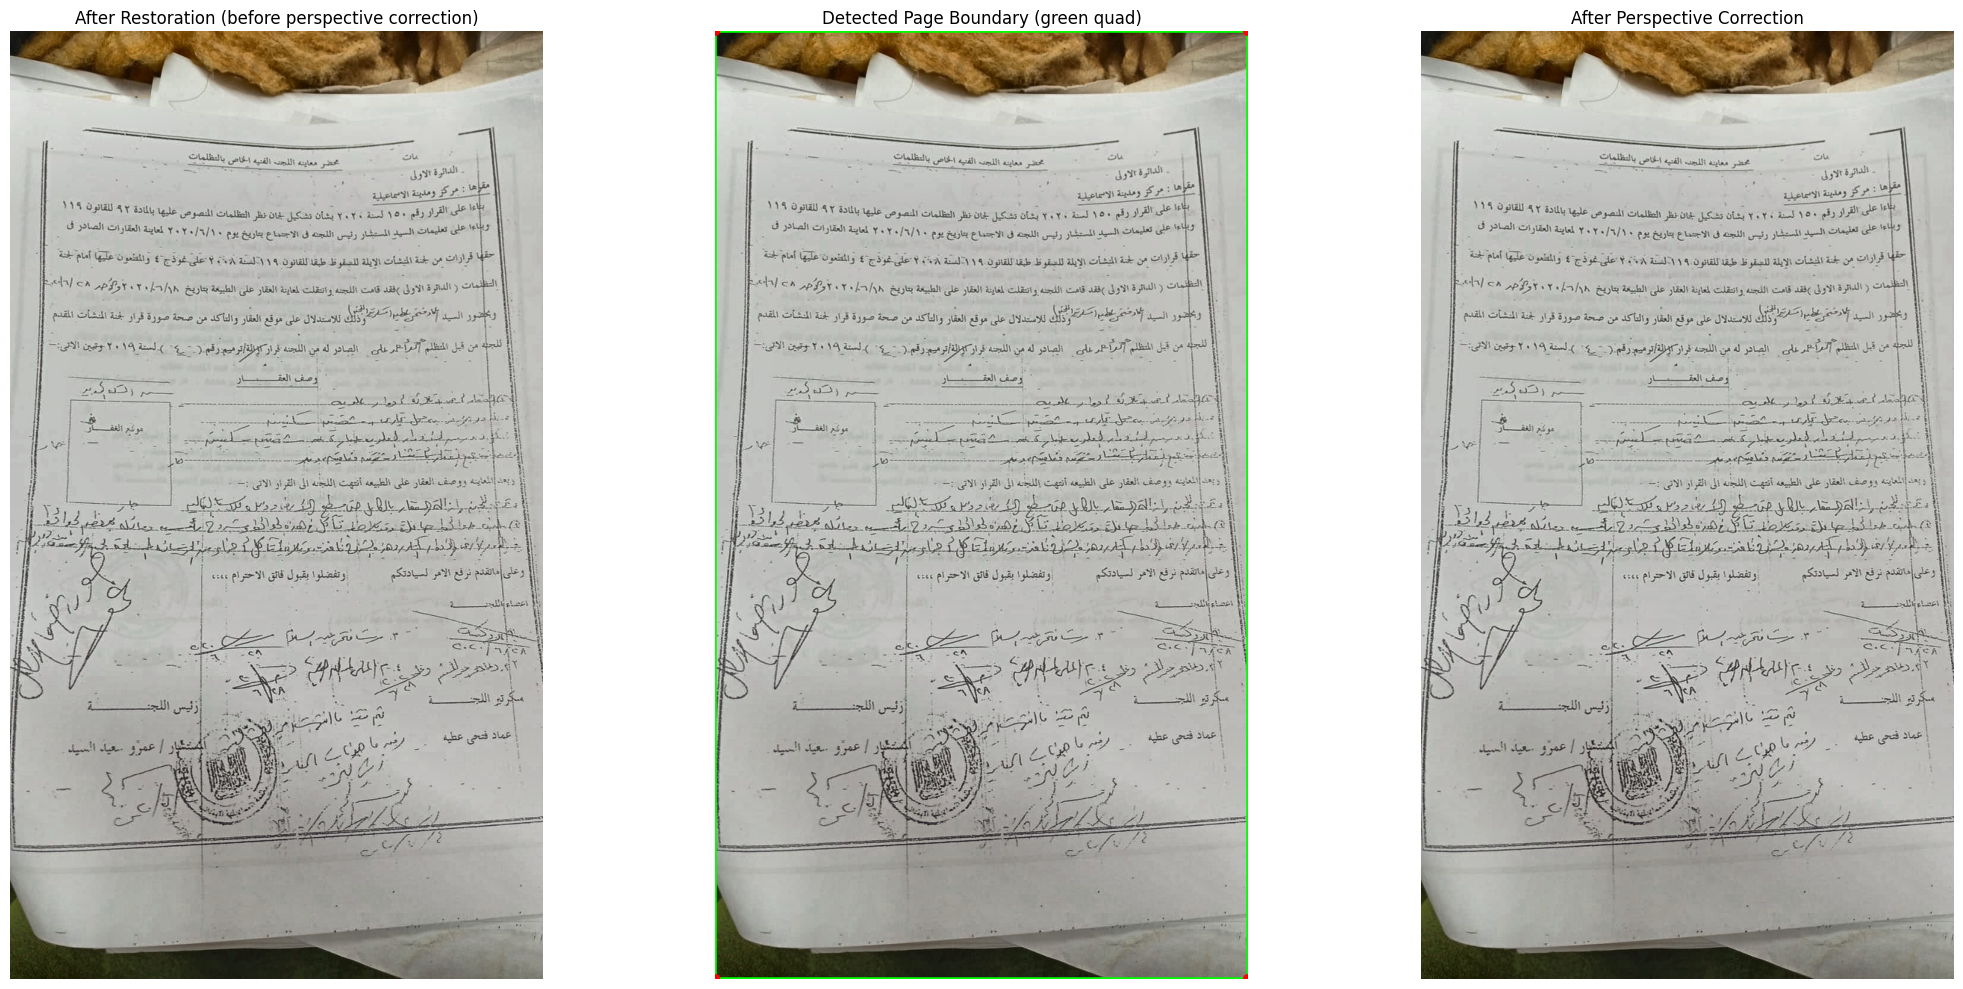

In [7]:
# Visual inspection cell -- before, detected boundary, after
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# Panel 1: After restoration (before perspective correction)
axes[0].imshow(restored_pages[0])
axes[0].set_title("After Restoration (before perspective correction)")
axes[0].axis("off")

# Panel 2: Detected boundary overlay on original
overlay = np.array(restored_pages[0]).copy()
page_quad = detect_page_contour(np.array(restored_pages[0]))
if page_quad is None:
    page_quad = detect_page_threshold(np.array(restored_pages[0]))
if page_quad is not None:
    pts = expand_quad(page_quad.astype(np.float32), overlay.shape, margin_pct=0.02)
    pts_int = pts.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(overlay, [pts_int], isClosed=True, color=(0, 255, 0), thickness=3)
    for pt in pts.astype(np.int32):
        cv2.circle(overlay, tuple(pt), 8, (255, 0, 0), -1)
    axes[1].set_title("Detected Page Boundary (green quad)")
else:
    axes[1].set_title("No Page Boundary Detected")
axes[1].imshow(overlay)
axes[1].axis("off")

# Panel 3: After perspective correction
axes[2].imshow(corrected_pages[0])
axes[2].set_title("After Perspective Correction")
axes[2].axis("off")

plt.tight_layout()
plt.show()


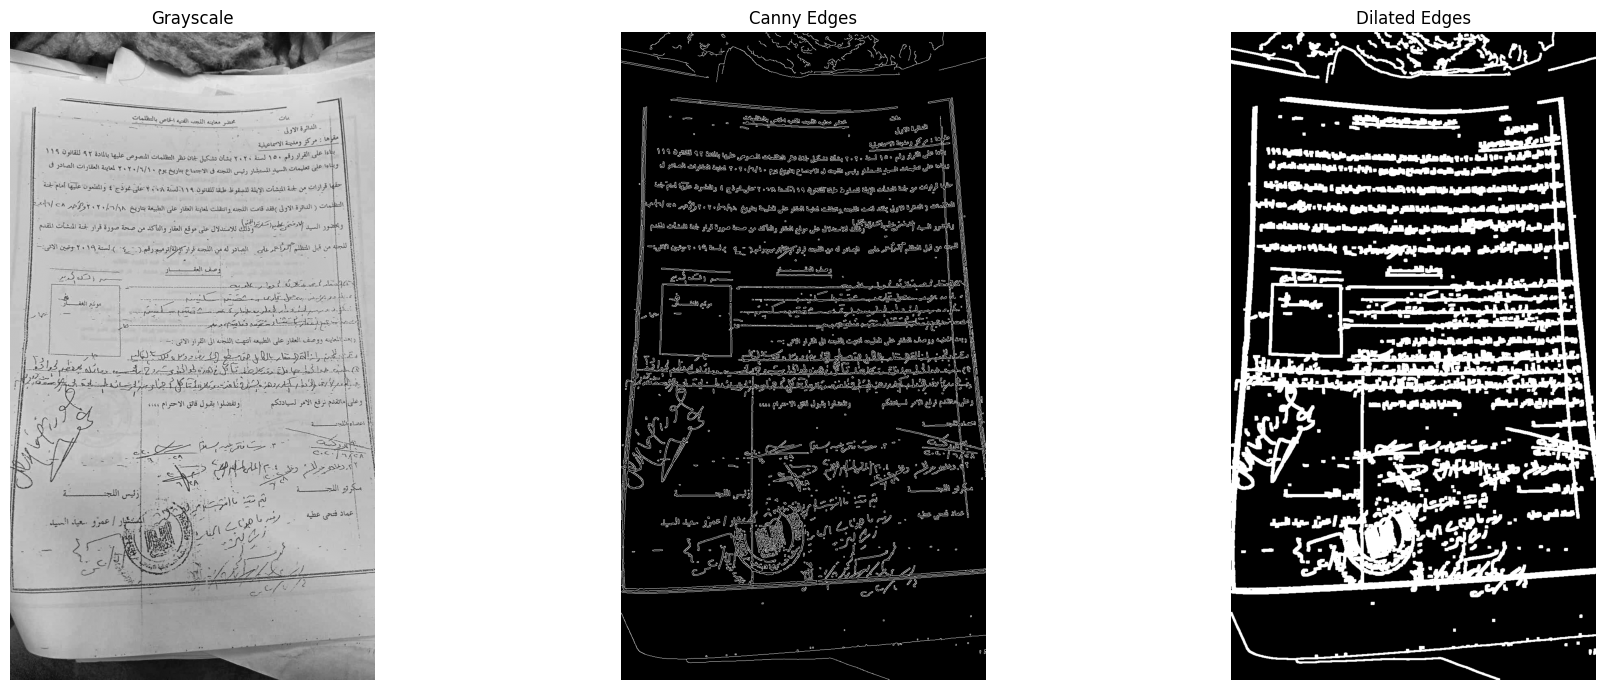

Image size: 899x1599 (area=1,437,501)
Contour 0: area=380,664 (26.5%), vertices=6
Contour 1: area=15,738 (1.1%), vertices=6
Contour 2: area=7,274 (0.5%), vertices=6
Contour 3: area=6,055 (0.4%), vertices=2
Contour 4: area=5,668 (0.4%), vertices=9


In [8]:
# Diagnostic: inspect edge detection intermediate results
test_img = np.array(restored_pages[0])
gray = cv2.cvtColor(test_img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
edges_dilated = cv2.dilate(edges, kernel, iterations=2)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges')
axes[1].axis('off')

axes[2].imshow(edges_dilated, cmap='gray')
axes[2].set_title('Dilated Edges')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Show contour detection result
contours, _ = cv2.findContours(edges_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)
h, w = test_img.shape[:2]
img_area = w * h
print(f'Image size: {w}x{h} (area={img_area:,})')
for i, cnt in enumerate(contours[:5]):
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    print(f'Contour {i}: area={area:,.0f} ({100*area/img_area:.1f}%), vertices={len(approx)}')


## 6. OCR Engine

Run QARI on each full page image. One inference call per page.
Includes a CUDA OOM error handler that logs the page and writes
an error entry to the output instead of crashing.

In [9]:
def ocr_page(pil_image: Image.Image, page_number: int) -> Dict[str, Any]:
    """
    Run QARI OCR on a single full-page PIL Image.

    Returns a dict with 'raw_text' or 'error'.
    """
    try:
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": pil_image},
                    {"type": "text", "text": OCR_PROMPT},
                ],
            }
        ]

        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )
        image_inputs, video_inputs = process_vision_info(messages)

        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to("cuda")

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

        generated_ids_trimmed = [
            out_ids[len(in_ids):]
            for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        output = processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]

        return {"raw_text": output.strip() if output else ""}

    except torch.cuda.OutOfMemoryError:
        logger.error("CUDA OOM on page %d — skipping.", page_number)
        torch.cuda.empty_cache()
        return {"error": "CUDA OOM \u2014 page skipped", "page": page_number}


# ── Run OCR on all pages ───────────────────────────────────────────────
ocr_results: List[Dict[str, Any]] = []

for i, page in enumerate(corrected_pages):
    page_num = i + 1
    print(f"OCR — page {page_num}/{len(corrected_pages)}...")

    t0 = time.time()
    result = ocr_page(page, page_num)
    elapsed = time.time() - t0

    ocr_results.append(result)
    print(f"Page {page_num} processed in {elapsed:.2f} seconds")

    if "error" in result:
        print(f"   ERROR: {result['error']}")
    else:
        text_len = len(result.get("raw_text", ""))
        preview = result.get("raw_text", "")[:120]
        print(f"   Text length: {text_len} chars")
        if preview:
            print(f"   Preview: {preview}...")

print(f"\nOCR complete: {len(ocr_results)} page(s) processed.")

OCR — page 1/1...
Page 1 processed in 703.91 seconds
   Text length: 5793 chars
   Preview: <p><u>محضر</u> معايئه <b>اللجب</b> الفني <i>الخاص</i> <u>بالتظلمات</u> <u>محضر</u> معايئه اللجب الفني الخاص بالظلمات</p>...

OCR complete: 1 page(s) processed.


##### Logged Runs Time:
1. 6 mins 17 secs (Sample 4) 
    - Result: Almost all words were captured (problem in image preprocessing)
2. 10 mins 29 secs (Sample 2)
    - Result: Almost no words were captured (problem in model's tokens)
3. 4 mins 55 secs (Sample 1)
    - Result: Almost all words were captured (problem in image preprocessing)
4. 11 mins 26 secs (Sample 5)
    - Result: Almost no handwritten word were extracted right, printed words were extracted just fine (problem in image preprocessing)
5. 2 mins 40 secs (Sample 2)
    - Result: Almpost perfect results (**Note:** Image Preprocessing never happened due to testing the new way)
6. 3 mins 27 secs (Sample 4)
    - Result: Pretty good results but the numbers aren't all correct

## 7. Text Reconstruction

Post-process the raw QARI output:
- Normalize Arabic-Indic and Persian numerals to Western digits
- Do NOT run any spell checking or grammar correction
- Store both the raw and normalized versions separately

In [10]:
def normalize_numerals(text: str) -> str:
    """
    Deterministic normalization of Arabic-Indic and Persian numerals
    to Western (ASCII) digits. No spell-checking or text correction.
    """
    arabic_indic = str.maketrans(
        '\u0660\u0661\u0662\u0663\u0664\u0665\u0666\u0667\u0668\u0669',
        '0123456789',
    )
    persian = str.maketrans(
        '\u06F0\u06F1\u06F2\u06F3\u06F4\u06F5\u06F6\u06F7\u06F8\u06F9',
        '0123456789',
    )
    text = text.translate(arabic_indic)
    text = text.translate(persian)
    return text


# ── Run reconstruction ─────────────────────────────────────────────────
reconstructed_pages: List[Dict[str, Any]] = []

for i, result in enumerate(ocr_results):
    page_num = i + 1

    if "error" in result:
        reconstructed_pages.append({
            "page_number": page_num,
            "perspective_corrected": page_corrections[i],
            "full_raw_text": "",
            "full_normalized_text": "",
            "error": result["error"],
        })
        continue

    raw_text = result.get("raw_text", "")
    normalized_text = normalize_numerals(raw_text)

    reconstructed_pages.append({
        "page_number": page_num,
        "perspective_corrected": page_corrections[i],
        "full_raw_text": raw_text,
        "full_normalized_text": normalized_text,
        "error": None,
    })

    print(f"Page {page_num}:")
    print(f"   Raw text length:        {len(raw_text)}")
    print(f"   Normalized text length:  {len(normalized_text)}")

print(f"\nReconstruction complete: {len(reconstructed_pages)} page(s)")

Page 1:
   Raw text length:        5793
   Normalized text length:  5793

Reconstruction complete: 1 page(s)


## 8. Output

Assemble the final structured JSON result and pretty-print it.

In [11]:
any_corrected = any(page_corrections)

output = {
    "metadata": {
        "filename": Path(FILE_PATH).name,
        "total_pages": len(reconstructed_pages),
        "model_used": MODEL_NAME,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "perspective_corrected": any_corrected,
    },
    "pages": reconstructed_pages,
}

print(json.dumps(output, indent=2, ensure_ascii=False))

{
  "metadata": {
    "filename": "Case_Sample(11).jpeg",
    "total_pages": 1,
    "model_used": "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct",
    "timestamp": "2026-04-05T13:07:18.244331+00:00",
    "perspective_corrected": true
  },
  "pages": [
    {
      "page_number": 1,
      "perspective_corrected": true,
      "full_raw_text": "<p><u>محضر</u> معايئه <b>اللجب</b> الفني <i>الخاص</i> <u>بالتظلمات</u> <u>محضر</u> معايئه اللجب الفني الخاص بالظلمات</p><br><p><u>الدائرة</u> الأولى</p><br><u>مقرها</u> : مركز ومدينة <u>الاساعيلية</u></p><br><p>بناءا على القرار رقم 15 <i>لسنة</i> 2000، <i>يشان</i> <i>تشكيل</i> <i>جان</i> نظر <b>الظلمات</b> <b>المنصوص</b> عليها بالمادة 91 للقانون 19 <i>ا</i> <i>وببناءا</i> على تعليمات <b>السيد</b> المستشار رئيس <b>اللجنة</b> في الاجتماع بتاريخ يوم <i>10</i> <i>يوليو</i> 2000/11/10 لمعاينة العقارات الصادر في حقها قرارات من لجنة <b>المنشآت</b> الإبلة للسقوط طبقا للقانون 19 <i>لسنة</i> 2000، <i>1</i> على <i>مذوج</i> <u>4،</u> <i>والطعون</i> <u>عليها</u> أمام

# 1st Output

ولمن كل ما سبق <u>اولا:</u> <b>بطلان</b> <u>قرار</u> <b>الازالة</b> تاسيسما <u>على</u> <u>:</u> <i>:</i> <b>ا</b> - انعدام صفة <i>مقدم</i> <i>الطلب</i> <i>.</i> <i>2-</i> ادعاء <i>مقدم</i> <i>الطلب</i> ان الغقار فارغ. <i>3-</i> عدم <i>اعلان</i> القيمين <i>بالعقار</i> <i>.</i> <i>4-</i> عدم <i>معايير</i> العقار والدليل ان <i>الطالب</i> لم يرى اللجنة في اي وقت. <u>ثانيا:</u> <i>اساءة</i> استعمال السلطة لكل <u>من</u> <u>اول</u> <u>الطرف</u> <i>الثاني</i> الى <u>الطرف</u> <i>الخامس.</i> <u>ثالثا:</u> حالة العقار <i>حالة</i> جيدة جدا ولا <u>خوف</u> <u>على</u> سكانه، <u>رابعا:</u> مراعاة <i>كون</i> الرجل يزيدعن <u>السبعون</u> عاما <u>ولا</u> <u>يجوز</u> <i>القاءه</i> في <i>الشارع</i> الا بعد <i>التأكد</i> منه <u>منة</u> <u>بالمائنة</u> <u>من</u> <u>حالة</u> <u>العقار</u> <i>وحيث</i> وجود قرار سابق لم <u>يعلن</u> <u>بع</u> <u>الطالب</u> <u>بالترميم.</u> <u>لذلك</u> يلتمس <i>الطالب</i> <u>.</u> لا <u>:</u> قبل <i>الطعن</i> <i>شكلا</i> <i>.</i> <u>اثنا:</u> الحكم بصفة مستعجلة <u>وقف</u> تنفيذ القرار رقم 150 لسنة 2020 الصادر من لجنة <i>الظلمات</i> في تاريخ 4/7/2020 <b>طبعون</b> فيه وما يترتب عليه من <i>اثار</i> على <u>أن</u> يتم تنفيذه بمسودة الحكم <u>.</u> <u>وا</u> <u>ثنا:</u> وفي الموضوع الغاء القرار المطبعون فيه واعتباره كان لم يكن <i>والغاء</i> كافة <i>الاثار</i> المترتبة عليه وشمول الحكم بالنفا <b>جل</b> طليقا من قيد <i>الكفالة</i> مع الزام المطبعون ضدهم بالمصروفات واتعاب المحاماه. <b>مع</b> حفظ كافة الحقوق <i>الاخرى</i> <u>.</u> <u>وكيلة</u> <u>الطالب</u>

# 2nd Ouput 

<p>القضاء الإداري بالإسماعيلية <i>.</i></p><br><h3><b>تحية</b> طيبة <b>وبعد،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،

# 3rd Output

<p><u>أولا:</u> بطلان القرار تأسيسا على <u>:</u> <u>م</u> <u>أ</u> <u>أن</u> <i>عدام</i> صفة مقدد <i>الطلب</i> الى <i>لجنة</i> التظلمات؟</p><br><p><i>المدعي</i> <b>عليه</b> <i>السابع</i> <i>ادعى</i> كونه مالكا <i>للعقار</i> ولم <i>يقدم</i> ما يثبت ادعاءه <b>وحيث</b> <i>ان</i> <i>التوكيل</i> لا يعتبر ناقلا <i>الملكية</i> <i>وحيث</i> ان المدعي <b>عليه</b> <i>السابع</i> لم <i>ثبت</i> له <b>ملكية</b> العقار حتى وقتنا هذا اذا فهو ليس ذو صفه ليتقدم باي <b>طلب</b> الى لجنة التظلمات ومادام <i>هو</i> ليس ذو صفه اذا خروج <i>اللجنة</i> اصلا <i>للماعينة</i> <i>باطل</i> فما <i>بني</i> على باطل فهو <i>باطل</i> .</p><br><p><u>ب:</u> <i>ادعى</i> <u>المدعي</u> <u>عليه</u> <u>السابع</u> <u>عند</u> <u>تقديم</u> <u>التظلم</u> ان العقار خالي من <u>السكان</u> <u>:</u> <i>ويجملة</i> الادعاءات <b>الباطلة</b> <i>التي</i> <i>قدمها</i> <i>المقابل</i> ادعاءه ان العقار <u>خالي</u> من السكان وهذا ما جعل اللجنة <b>تتهاون</b> في تقريرها <b>وتعديله</b> من <i>ترميم</i> الى <i>ازاله.</i></p><br><p><u>ج:</u> <i>عدم</i> <i>اعلن</i> اي من المقيمين في لبعقار <i>وذلك</i> لظنهم ان العقار خالي او لسبب <i>اخر</i> لا يعلمه <i>الا</i> <i>الله</i> ،فلم <i>يتسنى</i> <i>للطالب</i> او اي من المقيمين اتخاذ اي اجراء لايقاف <i>اصدار</i> القرار .</p><br><p><u>د:</u> عدم معاينة العقار ولا كانت <i>تعاملت</i> مع <i>الطالب</i> او اعلنته او علم اي شئ من كل تلك الاجراءات <i>.</i></p><br><p><u>ثانيا:</u> <u>اساءة</u> استعمال السلطة لكل من <i>اول</i> الطرف <u>الثاني</u> الى الطرف <i>الخامس</i> <u>مما</u> <u>يؤثر</u> <u>على</u> كافة <u>الاجراءات</u> <u>وتؤدي</u> <u>الى</u> <u>بطلاتها:</u> <u>.</u></p><br><p><i>وهذا</i> يبدو <i>جليا</i> حيث ان من الطرف <b>الثاني</b> الى الطرف <b>الخامس</b> بدءا من <i>اول</i> <u>:</u> <i>ا</i> - قبول طلب <i>الازالة</i> <i>والتظلم</i> من شخص لم يثبت كونه مالك العقار باي <i>وسيلة</i> <i>قانونية</i> حيث لا يعتبر <i>التوكيل</i> دليلي <i>ملكية</i> .</p><br><p>2 - عدم <i>اعلان</i> اي من <i>المقيمين</i> بالعقار او اعطاءهم الحق في اتخاذ اي من الاجراءات .</p><br><p>3 - <i>عدم</i> معاينة العقار او دخول اي من الشقق وخاصة <i>شقة</i> <i>الطالب</i> وهي بالدور <i>الارضي</i> والذي تم ذكره في التقرير مع انه لم <i>يدخل</i> اي من <i>اللجنة</i> الى تلك الشقة <u>فكيف</u> لها ان تكون قد عاينت <i>الدور</i> <i>الارضي.</i></p><br><h3><u>ثالثا:</u> <i>العقار</i> <u>محل</u> قرار الازالة <u>سليم</u> <u>ولا</u> <u>يوجد</u> <u>اي</u> <u>سبب</u> <u>للازالة</u> <u>:</u> <u>.</u></h3><br><p>بالرغم من عدم علم <i>الطالب</i> بالقرار الصادر من <i>اللجنة</i> بالترميم بحي ثان الاسماعيلية اللجنة <i>الاولى</i> رقم <u>4</u> لسنة 2019 <i>و</i> <i>الذي</i> صدر فيه قرار <i>بترميم</i> العقار واثبت انه لا خطورة على حياة ساكنيه.</p><br><h3>الا ان حالة العقار جيدة جدا وفي حالة وجود اي شئ يستحق <i>الترميم</i> سيتم ترميمه.</h3><br><h3>ومما <i>سبق</i> يتضح لذا ان الغرض وراء قرار الازالة ليس خوفا على <i>حياة</i> <i>أشخاص</i> ولكن رغبة في <i>ثراء</i> سريع ، فالقاء <i>رجل</i> كبير في <i>السن</i> تحدى <i>السبعون</i> من عمره عاش حياته <u>كلها</u> في تلك الشقة بالشارع وليس الا لرغبة في <b>حيازة</b> <i>المكان</i> وبناء <i>رج</i> سكني <b>مكانه</b> حيث ان هذا المنزل في احسن الامكان بالاسماعيلية .</h3>

# 4th Output

ولكنه التظلمات الدائره الاولي\n\nالسيد / محمد بن <b>وائل</b> <i>والمالك</i> <i>الجفر</i> <i>ريم</i> <u>وبي</u> <u>ل</u> <i>كل</i> <i>إليسا</i> <i>مر</i> <u>لهم</u> <u>تر</u> <u>تحيه</u> طبيبه وبعد بناءا على <i>التظلم</i> المقدم أمام لجنه <i>التظلمات</i> بالقانون 9 11 <i>البناء</i> الموحد بـ <i>رقم</i> <u>“8”</u> لسنه “2013” <u>م</u> <u>فقد</u> قامت <i>اللجنة</i> وانتقلت على <i>الطبيعه</i> للعقار <i>رقم</i> <u>“13”</u> شارع <i>“1”</i> <u>و14”</u> <u>كم</u> <u>إكيم</u> <u>م</u> <u>مر</u> <u>لهمه</u> <i>ص</i> <i>همه</i> <u>……</u> <u>وبعد</u> <b>المعاينه</b> ووصف العقار في محضر <b>المعاينه</b> أنتهت <i>اللجنة</i> الي الاتي / <u>تم</u> <u>البحث</u> <b>أوائله</b> <i>الدفء</i> <u>–</u> <i>بتشاور</i> <i>على</i> <i>مط</i> <i>د</i> <i>ربني</i> <i>وذلك</i> <i>المين</i> <i>جهود</i> <i>يجه</i> <i>الله</i> <i>مع</i> <i>تشاوره</i> <i>–</i> <i>ما</i> <i>كأن</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i>

# 5th Output

<p>ومن كل ما سبق</p><br><h2><u>اولا:</u> <u>بطلان</u> <u>قرار</u> <i>الازالة</i> <i>تاسيسا</i> <u>على</u> <u>ـ:</u></h2><br><p>ا- انعدام صفة مقدم <i>الطلب</i> .</p><br><p>2- <i>ادعاء</i> مقدم <i>الطلب</i> ان الغقار فارغ.3- عدم <i>اعلان</i> <i>القيمين</i> <i>بالعقار</i> .</p><br><p>4- عدم معاينة العقار <b>والدليل</b> <i>أن</i> <i>الطالب</i> لم يرى اللجنة في اي وقت.</p><br><h3><u>ثانيا:</u> <u>اساءة</u> <u>استعمال</u> <u>السلطة</u> <u>لكل</u> <u>من</u> <u>اول</u> <u>الطرف</u> <u>الثاني</u> الى <u>الطرف</u> <u>الخامسـ.</u></h3><br><h3><u>ثالثا:</u> <u>حالة</u> <u>العقار</u> حالة جيدة <u>جدا</u> <u>ولا</u> <u>خوف</u> <u>على</u> <u>سكانهـ.</u></h3><br><p><u>رابعا:</u> <u>مراعاة</u> <u>كون</u> <u>الرجل</u> <u>يزيدعن</u> <u>السبعون</u> <u>عاما</u> <u>ولا</u> <u>يجوز</u> القاءه في <i>الشارع</i> الا بعد <i>التاكد</i> <i>منه</i> <i>منة</i> <u>بالماناة</u> <u>من</u> حالة <u>العقار</u> <u>وحيث</u> وجود <u>قرار</u> سابق <u>لم</u> <u>يعلن</u> <u>بع</u> <u>الطالب</u> <u>بالترميمـ.</u></p><br><h1><u>توافر</u> ركن <u>الاستعجال</u></h1><br><p>نظرا <i>لأن</i> اي <i>تاخير</i> يؤدي الى طرد والقاء رجل على <b>المعاش</b> هو واسرته وغيره من الاسر على قارعة <b>الطريقـ.</b></p><br><h2><u>لذلك</u></h2><br><p>يلتمس <i>الطالب</i></p><br><p>اولاـ: قبل الطعن شكلا .</p><br><p>ثانياـ: الحكم بصفة مستعجلة بوقف تنفيذ القرار رقم 1 لسنة 2020 الصادر من لجنة <b>التنظيمات</b> في تاريخ 4/7/2020 المطلعون فيه وما يترتب عليه من اثار على ان يتم تنفيذه بمسودة الحكم .</p><br><p>ثالثاـ: وفي الموضوع الغاء القرار المطلعون فيه <i>واعتباره</i> كان لم يكن والغاء كافة <i>الإثار</i> المترتبة عليه وشمول الحكم بالنفاذ المعجل طليقا من قيد الكقالة مع الزام المطلعون ضدهم بالمصروفات واتعاب المحاماه.</p><br><p>مع حفظ كافة الحقوق <i>الاخرى</i></p><br><h2>وكيلة <u>الطالب</u></h2><br><h3>المحامية</h3>

# 6th Output

<h3><i>أماني</i> عبد <b>الحميد</b> <i>إبراهيم</i> المحامية <b>بالنقض</b> والإدارية العليا</h3><br><p><b>ت:</b> 12/4/2019</p><br><h3><i>دعاوى</i> الغاء قرار ازالة</h3><br><h4>السيد الاستاذ المستشار / رئيس محكمة القضاء الإداري بالإسماعيلية .</h4><br><p><b>تحية</b> طيبة وبعد،،،،،</p><br><p><i>مقدمه</i> لسيادتكم / محمد <b>محمد</b> <b>إبراهيم</b> سعيد <i>–</i> <i>المقيم</i> بالغقار رقم 27 شارع السكة الحديد سابقا 27 شارع <i>شحته</i> حاليا عرايشية مصر <i>–</i> <i>ثان</i> <i>الاسماعيلية</i> ومحله المختار مكتب <i>الاستاذة</i> / اماني عبدالحميد <b>إبراهيم</b> المحامية بالنقض والاستاذ/ طارق رضا محمد علي المحامي بالإسماعيلية.</p><br><h3><u>ضـد</u></h3><br><p><b>بصفته</b> <i>أ</i> - السيد/ <i>محافظ</i> <i>الاسماعيلية</i></p><br><p>أ- السيد/ رئيس مركز ومدينة <i>الاسماعيلية</i></p><br><p>أ- السيد/ رئيس <i>الادارة</i> الهندسية بحي ثان <u>الاسماعيلية</u></p><br><p>ثـ <i>-</i> السيد/ رئيس <b>حي</b> ثان <i>الاسماعيلية</i></p><br><p>هـ السيد/ مدير عام مديرية <i>السكان</i> بالإسماعيلية</p><br><p>آـ السيد/ <i>عميد</i> مامور قسم ثان <i>الاسماعيلية</i></p><br><h4><i>وعلنوا</i> جميعا بهيئة قضايا الدولة بالإسماعيلية</h4><br><h4>أ- السيد / محمد احمد <i>علي</i> – المقاول – صاحب شركة محمد علي للمقاولات والانشاء والاستثمرات العقارية <u>–</u> <b>والمقيم</b> <u>خلف</u> رضا <b>حلمي</b> للمشويات بشارع شبين <i>الكوم</i> <i>–</i> ثالث <i>الاسماعيلية.</i></h4><br><h2><u>الموضوع</u></h2><br><p><b>بموجب</b> عقد الاجار المؤرخ <i>اول</i> <i>اغسطس</i> 1959 اجر المدعي <i>الشقة</i> بالدور الارضي بالعقار رقم 27 شارع السكة الحديد سابقا 27 شارع <i>شحته</i> حاليا عرايشية مصر <i>–</i> <i>ثان</i> <i>الاسماعيلية</i> ، <b>قيم</b> <b>الطالب</b> <u>بتلك</u> الشقة من تاريخ عقد الاجار حتى <i>وقتنا</i> هذا حيث قضى فيها عمره <i>كله</i> <u>شيائه</u> ورجولته وكبره، <u>قيم</u> <b>الطالب</b> اقامة هادئة مستقرة بدون اي مشاكل ويسدد دائما <b>القيمة</b> الاجيارية الخاصة به.</p><br><h3>لما فوجئ <i>الطالب</i> بوجود قرار ازالة رقم 1 لسنة 2020 والصادر <i>بازالة</i> العقار بالكامل حتى سطح الارض ،.</h3><br><p>ولما كان قرار لجنة <i>الظلمات</i> <u>قد</u> جاء <b>بطريقة</b> مخالفة للقانون وقد انتفته السرية <i>التامة</i> ولم يتم <i>اعلان</i> <i>الطالب</i> باي من <i>إجراءات</i> <i>اللجنة</i> من اي اجراءاتها ، ان كان <i>المنتظم</i> او <i>اللجنة</i> ذاتها ، <u>وعند</u> <i>تتبعه</i> للام فوجئ <b>بأنه</b> قد <u>سبق</u> قرار <i>الازالة</i> قرار <i>ترميم</i> <i>رقم</i> <u>2</u> لسنة 2019 ولم <i>يلعن</i> به <u>ايضا</u> .</p>

<p><u>محضر</u> معايئه <b>اللجب</b> الفني <i>الخاص</i> <u>بالتظلمات</u> <u>محضر</u> معايئه اللجب الفني الخاص بالظلمات</p><br><p><u>الدائرة</u> الأولى</p><br><u>مقرها</u> : مركز ومدينة <u>الاساعيلية</u></p><br><p>بناءا على القرار رقم 15 <i>لسنة</i> 2000، <i>يشان</i> <i>تشكيل</i> <i>جان</i> نظر <b>الظلمات</b> <b>المنصوص</b> عليها بالمادة 91 للقانون 19 <i>ا</i> <i>وببناءا</i> على تعليمات <b>السيد</b> المستشار رئيس <b>اللجنة</b> في الاجتماع بتاريخ يوم <i>10</i> <i>يوليو</i> 2000/11/10 لمعاينة العقارات الصادر في حقها قرارات من لجنة <b>المنشآت</b> الإبلة للسقوط طبقا للقانون 19 <i>لسنة</i> 2000، <i>1</i> على <i>مذوج</i> <u>4،</u> <i>والطعون</i> <u>عليها</u> أمام لجنة <b>الظلمات</b> ( الدائرة الأولى) فقد قامت اللجبه <b>وانتقلت</b> لمعاينة العقار على الطبيعة بتاريخ 18 <i>يوليو</i> 2000/11/18 <i>وكتم</i> <i>8</i> <u>ا</u> <u>أ</u> <u>ب</u> <b>ب</b> <i>وبحضور</i> السيد <u>الجاحشمر</u> <u>الطيب</u> <u>(سندتة</u> <u>الثقة)</u> <b>وذلك</b> للاستدلال على موقع العقار <b>والتأكد</b> من صحة صورة قرار لجنة <b>المنشآت</b> <i>القدم</i> للجنه من قبل <i>المنتظم</i> <u>أعمام</u> <i>لهم</i> على الصادر له من اللجبه <i>قرار</i> الإبلة/توميم رقم <u>(_ع،</u> 19 <i>لسنة</i> 2000) وتمين الاتى:–</p><br><p><u>وصف</u> <u>العق</u> <u>مار</u> <b>،</b> <i>وكتم</i> <i>لهم</i> <i>لست</i> <i>بذلك</i> <u>كمس</u> <u>،</u> <u>1</u> <u>ووا</u> <u>1</u> <u>عام</u> <u>م</u> <u>،</u> <u>وكان</u> <u>م</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>مع</u> <u>على</u> <u>ذلك</u> <u>كمس</u> <u>،</u> <u>مظَمَم</u> <u>كمس</u> <u>،</u> <u>وكان</u> <u>